In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data" / "raw"

train_features = pd.read_csv(DATA_DIR / "training_set_features.csv")
train_labels = pd.read_csv(DATA_DIR / "training_set_labels.csv")
test_features = pd.read_csv(DATA_DIR / "test_set_features.csv")

targets = ["h1n1_vaccine", "seasonal_vaccine"]
df = train_features.merge(train_labels, on="respondent_id")

print(train_features.shape, train_labels.shape, test_features.shape)

(26707, 36) (26707, 3) (26708, 36)


In [2]:
print(df[targets].mean().round(3))
print(pd.crosstab(df.h1n1_vaccine, df.seasonal_vaccine, margins=True))
print("Correlation:", round(df.h1n1_vaccine.corr(df.seasonal_vaccine), 3))

h1n1_vaccine        0.212
seasonal_vaccine    0.466
dtype: float64
seasonal_vaccine      0      1    All
h1n1_vaccine                         
0                 13295   7738  21033
1                   977   4697   5674
All               14272  12435  26707
Correlation: 0.377


Expected: uptake of about 0.212 (H1N1) and 0.466 (seasonal), and a correlation of about 0.377.

employment_occupation          50.4
employment_industry            49.9
health_insurance               46.0
income_poverty                 16.6
doctor_recc_seasonal            8.1
doctor_recc_h1n1                8.1
rent_or_own                     7.6
employment_status               5.5
education                       5.3
marital_status                  5.3
chronic_med_condition           3.6
child_under_6_months            3.1
health_worker                   3.0
opinion_seas_sick_from_vacc     2.0
opinion_seas_risk               1.9
opinion_seas_vacc_effective     1.7
opinion_h1n1_sick_from_vacc     1.5
opinion_h1n1_risk               1.5
opinion_h1n1_vacc_effective     1.5
household_children              0.9
household_adults                0.9
behavioral_avoidance            0.8
behavioral_touch_face           0.5
h1n1_knowledge                  0.4
h1n1_concern                    0.3
behavioral_antiviral_meds       0.3
behavioral_large_gatherings     0.3
behavioral_outside_home     

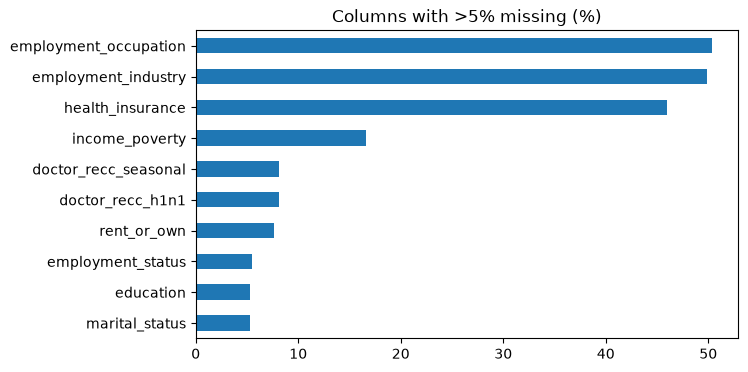

In [3]:
missing = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
print(missing[missing > 0])

missing[missing > 5].plot.barh(figsize=(7, 4), title="Columns with >5% missing (%)")
plt.gca().invert_yaxis()
plt.show()

In [4]:
def uptake_by(col, order=None):
    out = (df.assign(**{col: df[col].fillna("Missing")})
             .groupby(col)[targets].mean().round(2))
    out["n"] = df.assign(**{col: df[col].fillna("Missing")}).groupby(col).size()
    return out.loc[order] if order else out

uptake_by("opinion_h1n1_vacc_effective")

,h1n1_vaccine,seasonal_vaccine,n
opinion_h1n1_vacc_effective,,,
1.0,0.05,0.21,886
2.0,0.05,0.26,1858
3.0,0.11,0.42,4723
4.0,0.18,0.45,11683
5.0,0.40,0.61,7166
Missing,0.19,0.38,391


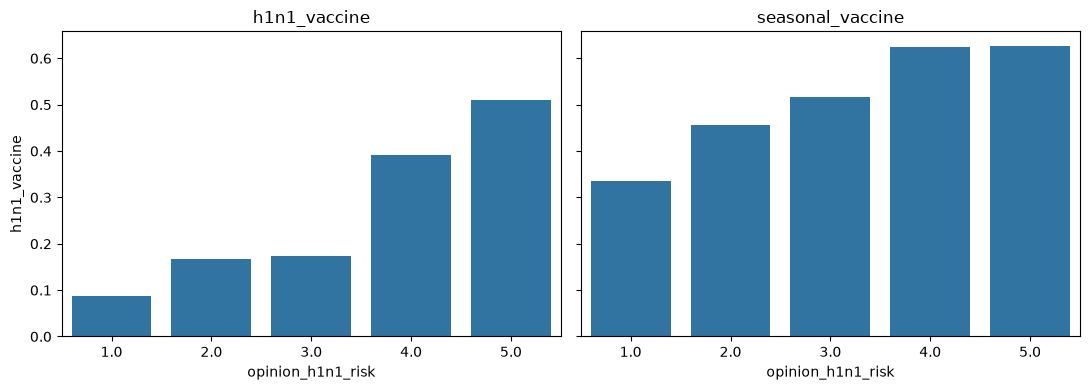

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, t in zip(axes, targets):
    sns.barplot(data=df, x="opinion_h1n1_risk", y=t, ax=ax, errorbar=None)
    ax.set_title(t)
plt.tight_layout()
plt.show()

In [6]:
df["combo"] = df.h1n1_vaccine.astype(int).astype(str) + df.seasonal_vaccine.astype(int).astype(str)
df["combo"] = df["combo"].map({"00": "Neither", "01": "Seasonal only", "10": "H1N1 only", "11": "Both"})

print(df.combo.value_counts(normalize=True).round(3))

# Which group does each feature separate best?
pd.crosstab(df["age_group"], df["combo"], normalize="index").round(2)

combo
Neither          0.498
Seasonal only    0.290
Both             0.176
H1N1 only        0.037
Name: proportion, dtype: float64


combo,Both,H1N1 only,Neither,Seasonal only
age_group,,,,
18 - 34 Years,0.13,0.06,0.66,0.15
35 - 44 Years,0.15,0.05,0.59,0.21
45 - 54 Years,0.16,0.03,0.56,0.24
55 - 64 Years,0.21,0.03,0.46,0.30
65+ Years,0.20,0.02,0.30,0.47


In [7]:
def uptake_table(col):
    g = df.assign(**{col: df[col].fillna("Missing")}).groupby(col)
    return g[targets].mean().round(2).assign(n=g.size()).sort_values("seasonal_vaccine")

uptake_table("hhs_geo_region")
uptake_table("employment_occupation")

# Are occupation effects just health workers?
uptake_table("employment_occupation").join(
    df.groupby(df.employment_occupation.fillna("Missing")).health_worker.mean().round(2))

,h1n1_vaccine,seasonal_vaccine,n,health_worker
employment_occupation,,,,
qxajmpny,0.11,0.20,548,0.03
uqqtjvyb,0.12,0.25,452,0.04
tfqavkke,0.14,0.28,388,0.08
pvmttkik,0.14,0.29,98,0.02
rcertsgn,0.09,0.32,276,0.07
xqwwgdyp,0.14,0.33,485,0.02
xgwztkwe,0.13,0.34,1082,0.04
ccgxvspp,0.15,0.35,341,0.01
ukymxvdu,0.19,0.35,372,0.05


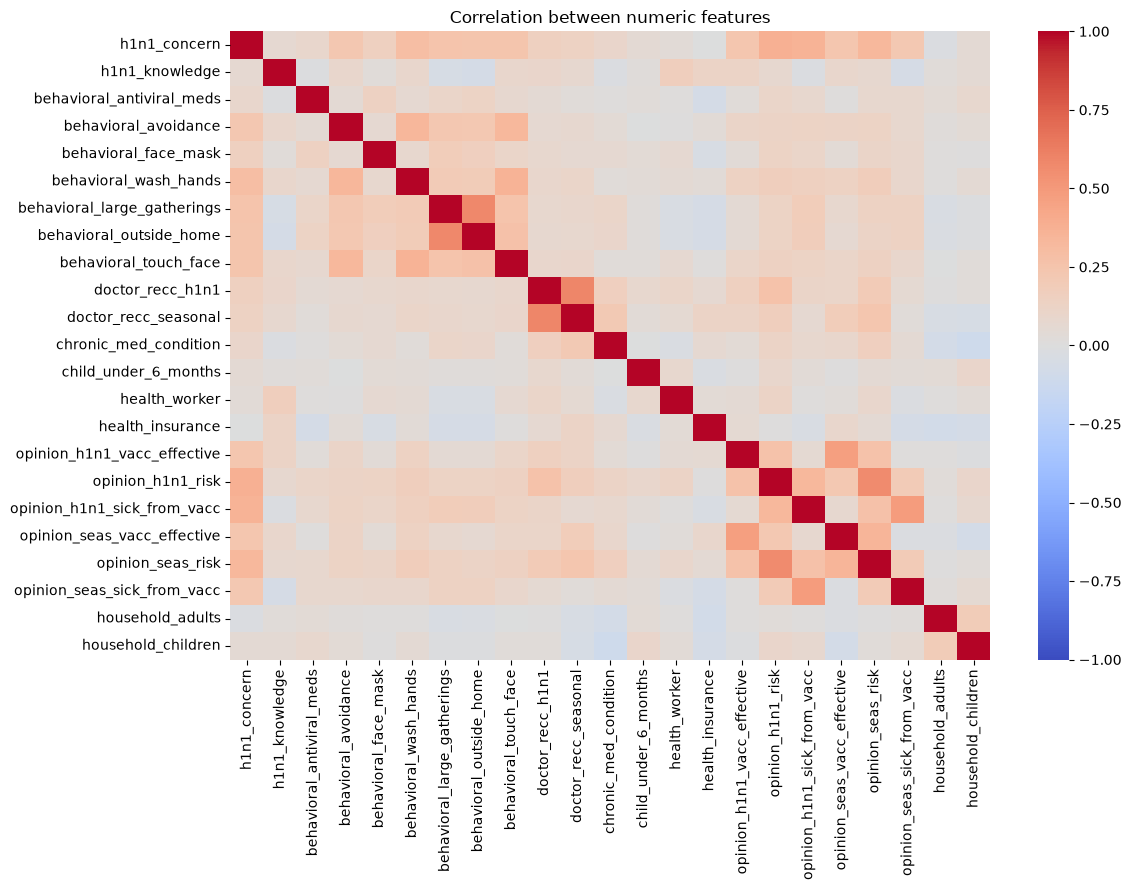

In [9]:
num = train_features.select_dtypes("number").drop(columns="respondent_id")

plt.figure(figsize=(12, 9))
sns.heatmap(num.corr(), cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation between numeric features")
plt.tight_layout()
plt.show()

# Exploring Vaccination Patterns: Findings from EDA

## 1. Dataset overview
- Training data: 26,707 respondents, 35 features, and two targets (`h1n1_vaccine`, `seasonal_vaccine`). The test set has 26,708 respondents.
- H1N1 uptake is 21.2% (imbalanced), seasonal flu uptake is 46.6% (roughly balanced).
- Heaviest missingness: `employment_occupation` (~50%), `employment_industry` (~50%), `health_insurance` (~46%), `income_poverty` (~17%).

## 2. How the two vaccines relate
The vaccines are not either/or choices. Combining the two targets gives four outcomes:

| Outcome | Share |
|---|---|
| Neither | 49.8% |
| Seasonal only | 29.0% |
| Both | 17.6% |
| H1N1 only | 3.7% |

- The correlation between the two targets is about 0.38.
- H1N1-only is rare, so most people who got the H1N1 vaccine also got the seasonal one.
- **Implication:** the targets are related enough to consider modeling them jointly, but the correlation is moderate, so separate